# Atractor de Lorenz.

In [3]:
%%html
<iframe width="600" height="400" src="https://www.youtube.com/embed/XZ7Ly7dDCzo" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" allowfullscreen></iframe>

# Introducción.

En 1963 Edward Lorenz en 1963 desarrolló un modelo que describe la convección atmosférica. Se basó en una descripción simple de nuestra atmósfera: 

* Imagina una porción rectangular de aire calentada desde abajo y enfriada desde arriba. 
* La parte inferior es calentada por la tierra y la parte superior es enfriada por el vacío del espacio exterior. 
* Dentro de esta porción, el aire caliente sube y el aire frío se hunde.
* El estado de la atmósfera en este modelo se puede describir mediante tres variables que evolucionan en el tiempo:

    - $x$ : el flujo convectivo
    - $y$ : la distribución horizontal de la temperatura
    - $z$ : la distribución vertical de la temperatura

* También se usan tres parámetros que describen el carácter del modelo:

    - $\sigma$ : la relación entre viscosidad y conductividad térmica (número de Prandtl).
    - $\rho$ : la diferencia de temperatura entre la parte superior e inferior de la rebanada (número de Rayleigh).
    - $\beta$ : la relación ancho-alto de la rebanada.

* El sistema ecuaciones diferenciales ordinarias de este modelo son:

$$
\begin{eqnarray}
\dfrac{dx}{dt} & = & \sigma (y - x) \\
\dfrac{dy}{dt} & = & x (\rho - z) - y\\
\dfrac{dz}{dt} & = & xy - \beta z \\
\end{eqnarray}
$$

* El sistema definido por Lorenz presenta un comportamiento caótico y suele aparecer también en otros fenómenos como modelos de láseres, dínamos, termosifones, motores de corriente continua sin escobillas, circuitos eléctricos y reacciones químicas. 

* El número de Prandtl y el número de Rayleigh son parámetros adimensionales que definen el movimiento convectivo en la atmósfera.

* Cuando  $\sigma = 10$, $\beta = 8/3$, $\rho = 28$ el sistema exhibe un comportamiento **caótico**. Una condición es que se debe cumplir que $\sigma, \beta, \rho > 0$.

* Dadas las condiciones iniciales, la solución de este sistema define trayectorias en el espacio fase $xyz$ cuya forma recuerdan a una mariposa; de aquí que el atractor de Lorenz puede haber inspirado el nombre del **efecto mariposa** en la teoría del caos.


<div class="alert alert-success">

## Ejercicio 1.

Resolver numéricamente las ecuaciones de Lorenz y dibujar las trayectorias en el espacio fase $x − y − z$ para $N$ posiciones iniciales elegidas aletoriamente como se muestra en la siguiente figura y video: 

<table style="width:100%">
  <tr>
     <td style="text-align:center"><img src="./lorenz.png"  width='300px' style="float: left"/></td>
    <td style="text-align:center"><video src="./lorenz.mp4" width="320" controls></video></td>
  </tr>
</table>

* Inicia con una posición inicial $(0, 1, 1.05)$ y los siguientes valores de los parámetros $\sigma = 10$, $\beta = 8/3$, $\rho = 28$.

</div>

## Modelo Numérico

El sistema representado por las ecuaciones $(1), (2)$ y $(3)$ puede ser resuelto numéricamente aplicando el método de Euler hacia adelante. Con dicho método obtenemos las siguientes ecuaciones en diferencias, cuya aprocimación es de orden lineal $\mathcal{O}(h_t)$:

$$
\begin{eqnarray}
x(t_{n+1}) & = & x(t_n) + h_t * F\big(t_n, x(t_n), y(t_n), z(t_n)\big) \tag{4}\\
y(t_{n+1}) & = & y(t_n) + h_t * G\big(t_n, x(t_n), y(t_n), z(t_n)\big) \tag{5}\\
z(t_{n+1}) & = & z(t_n) + h_t * H\big(t_n, x(t_n), y(t_n), z(t_n)\big) \tag{6}
\end{eqnarray}
$$

donde:

$$
\begin{eqnarray}
F\big(t_n, x(t_n), y(t_n), z(t_n)\big) & = & \sigma * \big(y(t_n) − x(t_n)\big) \tag{7} \\
G\big(t_n, x(t_n), y(t_n), z(t_n)\big) & = & x(t_n) * \big(\rho − z(t_n) \big) − y(t_n) \tag{8}\\
H\big(t_n, x(t_n), y(t_n), z(t_n)\big) & = & x(t_n) * y(t_n) − \beta * z(t_n) \tag{9}
\end{eqnarray}
$$

Para que el método esté bien definido necesitamos condiciones iniciales:

$$
\begin{eqnarray}
x(t = 0) & = & x_0 \\
y(t = 0) & = & y_0 \\
z(t = 0) & = & z_0 \\
\end{eqnarray}
$$

Al resolver este problema obtendremos una lista de tuplas del tipo $(x_n,y_n,z_n)$ para $n=1, \dots, N_t$, que al graficarse generarán trayectorias en el espacio fase $xyz$.

En el siguiente interactivo mueva el valor de los parámetros y observe lo que sucede.

In [35]:
import matplotlib.pyplot as plt
import numpy as np

In [58]:
# Parámetros del sistema de ecuaciones de Lorenz
𝜎 = 10.0 # Número de Prandtl
𝜌 = 28.0 # Número de Rayleigh
𝛽 = 8./3 

Nt = 10 # Número total de pasos
dt = 0.01 # Stepsize

# Posiciones iniciales
x0 = np.array([0.0, 1.0, 1.05])

# Arreglos para almacenar las coordenadas de las trayectorias
x = np.zeros(Nt)
y = np.zeros(Nt)
z = np.zeros(Nt)

# Condición inicial.
x[0] = x0[0]
y[0] = x0[1]
z[0] = x0[2]

print('Número de Prandtl 𝜎 : {}'.format(𝜎))
print('Número de Rayleigh 𝜌 : {}'.format(𝜌))
print('Valor de 𝛽 : {}'.format(𝛽))
print('Numero total de pasos en el tiempo: {}'.format(Nt))
print('Tamaño del paso de tiempo: {}'.format(dt))
print('Posición inicial de la trayectoria: {}'.format(x0))

print(x)
print(y)
print(z)

Número de Prandtl 𝜎 : 10.0
Número de Rayleigh 𝜌 : 28.0
Valor de 𝛽 : 2.6666666666666665
Numero total de pasos en el tiempo: 10
Tamaño del paso de tiempo: 0.01
Posición inicial de la trayectoria: [0.   1.   1.05]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1.05 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]


In [59]:
# Solución de las ecs. de Lorenz usando el método de Euler hacia adelante
for n in range(0, Nt-1):
    x[n+1] = x[n] + dt * ( 𝜎 * (y[n] - x[n]) )
    y[n+1] = y[n] + dt * ( x[n] * (𝜌 - z[n]) - y[n] )
    z[n+1] = z[n] + dt * ( x[n] * y[n] - 𝛽 * z[n] )

print(x)
print(y)
print(z)

[0.         0.1        0.189      0.2708078  0.34853155 0.42475452
 0.50167289 0.58120503 0.6650788  0.75490211]
[1.         0.99       1.007078   1.04804528 1.11076123 1.19393827
 1.29699429 1.41994267 1.56331199 1.72808921]
[1.05       1.022      0.99573667 0.97108707 0.9480296  0.92662016
 0.9069816  0.88930209 0.87384015 0.860935  ]


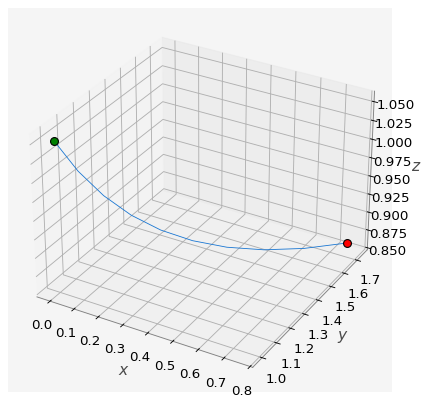

In [60]:
# Graficación de las trayectorias en el espacio fase
fig = plt.figure();
ax = fig.add_axes([0, 0, 1, 1], projection='3d');
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')

# Graficamos la condicion inicial
ax.scatter(x[0], y[0], z[0], fc='green', ec='k', s = 50, zorder=10) 

# Graficamos la trayectoria
ax.plot(x, y, z, '-', lw='0.75')

# Graficamos la posición final
ax.scatter(x[-1], y[-1], z[-1], fc='red', ec='k', s = 50, zorder=5)

plt.show()

<div class="alert alert-success">

## Proyecto 2.

Seleccionar uno de los atractores que se describen en el siguiente sitio: [Atractores extraños](https://www.dynamicmath.xyz/strange-attractors/) y construir al menos 10 trayectorias para diferentes condiciones iniciales usando:

* Método de Euler.
* Uno método de R-K.
* Construir un interactivo para variar alguno de los parámetros.
* Realizar una presentación en equipo presentando:
    - Presentación del problema y del equipo (30 segundos)
    - Modelo conceptual y matemático (1:30 min).
    - Modelo numérico (3 min).
    - Modelo computacional (3 min).

</div>